In [1]:
from mlwpy import *
%matplotlib inline

diabetes = datasets.load_diabetes()

tts = skms.train_test_split(diabetes.data, diabetes.target,test_size=.25,random_state=42)
(diabetes_train_ftrs, diabetes_test_ftrs,diabetes_train_tgt,diabetes_test_tgt) = tts

#### Baseline Regressors


In [2]:
strategies = ['constant','quantile','mean','median']
baseline_args = [{"strategy":x} for x in strategies]

##lets add quantile and constants
baseline_args[0]["constant"]=50
baseline_args[1]["quantile"] = 0.75

def do_one(**args):
    baseline = dummy.DummyRegressor(**args)
    preds = (baseline.fit(diabetes_train_ftrs,diabetes_train_tgt).predict(diabetes_test_ftrs))
    return metrics.mean_squared_error(diabetes_test_tgt, preds)

mses = [do_one(**bla) for bla in baseline_args] 
df = pd.DataFrame({'mse':mses},index=strategies)
display(df)

,mse
constant,"14,657.6847"
quantile,"10,216.3874"
mean,"5,607.1979"
median,"5,542.2252"


#### Creating a scorer

In [3]:
def rms_error(actual,predicted):
    mse = metrics.mean_squared_error(actual, predicted)
    return np.sqrt(mse)

def neg_rmse(actual,predicted):
    return -rms_error(actual,predicted)

def my_scorer(model,ftrs,tgt_actual):
    tgt_pred = model.predict(ftrs)
    return neg_rmse(tgt_actual,tgt_pred)

knn = neighbors.KNeighborsRegressor(n_neighbors = 3)
skms.cross_val_score(knn,diabetes.data,diabetes.target,cv=skms.KFold(5, shuffle=True),scoring=my_scorer)



array([-58.0034, -64.9886, -63.1431, -61.8124, -57.6243])

In [4]:
lr = linear_model.LinearRegression()

help(lr.score)
print(lr.score.__doc__.splitlines()[0])

Help on method score in module sklearn.base:

score(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Return the coefficient of determination of the prediction.

    The coefficient of determination :math:`R^2` is defined as
    :math:`(1 - \frac{u}{v})`, where :math:`u` is the residual
    sum of squares ``((y_true - y_pred)** 2).sum()`` and :math:`v`
    is the total sum of squares ``((y_true - y_true.mean()) ** 2).sum()``.
    The best possible score is 1.0 and it can be negative (because the
    model can be arbitrarily worse). A constant model that always predicts
    the expected value of `y`, disregarding the input features, would get
    a :math:`R^2` score of 0.0.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Test samples. For some estimators this may be a precomputed
        kernel matrix or a list of generic objects instead with shape
        ``(n_samples, n_samples_fitted)``, where ``n_s

$$R^2$$


In [5]:
our_preds = np.array([1,2,3])
mean_preds = np.array([2,2,2])
actual_preds = np.array([2,3,4])

sse_ours = np.sum((our_preds- actual_preds)**2)
sse_mean = np.sum((mean_preds- actual_preds)**2)



In [6]:
r_2 = 1 -(sse_ours/sse_mean)
print("manual r2:{:5.2f}".format(r_2))

manual r2: 0.40


In [7]:
baseline = dummy.DummyRegressor(strategy = 'mean')

baseline.fit(diabetes_train_ftrs, diabetes_train_tgt)
base_preds = baseline.predict(diabetes_test_ftrs)

# r2 is not symmetric true values have priorities
base_r2_sklearn = metrics.r2_score(diabetes_test_tgt, base_preds)
print(base_r2_sklearn)

-0.014016723490579253


In [8]:
base_errors = base_preds - diabetes_test_tgt
sse_base_preds = np.dot(base_errors,base_errors)

#train_mean to predict test targets
train_mean_errors = np.mean(diabetes_train_tgt) - diabetes_test_tgt
sse_mean_train = np.dot(train_mean_errors,train_mean_errors)

#test_mean to predict test targets
test_mean_errors = np.mean(diabetes_test_tgt) - diabetes_test_tgt
sse_mean_test = np.dot(test_mean_errors,test_mean_errors)

print("sklearn train_mean model  SSE(on test):", sse_base_preds)
print("manual train_mean model  SSE(on test):", sse_mean_train)
print("manual test_mean model  SSE(on test):", sse_mean_test)

sklearn train_mean model  SSE(on test): 622398.9703179051
manual train_mean model  SSE(on test): 622398.9703179051
manual test_mean model  SSE(on test): 613795.5675675676


In [9]:
1- (sse_base_preds/sse_mean_test)

-0.014016723490578809

In [10]:
print(base_r2_sklearn)
print(1- (sse_base_preds/sse_mean_test))

-0.014016723490579253
-0.014016723490578809


In [11]:
# 
# WARNING!  Don't try this at home boys & girls!
# we are fitting on the *test* set ... to mimic the behavior 
# of sklearn R^2.
#
testbase = dummy.DummyRegressor(strategy='mean')
testbase.fit(diabetes_test_ftrs, diabetes_test_tgt)
testbase_preds = testbase.predict(diabetes_test_ftrs)
testbase_mse = metrics.mean_squared_error(testbase_preds, 
                                          diabetes_test_tgt)

models = [neighbors.KNeighborsRegressor(n_neighbors=3),
          linear_model.LinearRegression()]
results = co.defaultdict(dict)
for m in models:
    preds = (m.fit(diabetes_train_ftrs, diabetes_train_tgt)
              .predict(diabetes_test_ftrs))
             
    mse = metrics.mean_squared_error(preds, diabetes_test_tgt)
    r2  = metrics.r2_score(diabetes_test_tgt, preds)
    results[get_model_name(m)]['R^2'] = r2
    results[get_model_name(m)]['MSE'] = mse

print(testbase_mse)

df = pd.DataFrame(results).T
df['Norm_MSE'] = df['MSE'] / testbase_mse
df['1-R^2'] = 1-df['R^2']
display(df)

5529.689797906013


,R^2,MSE,Norm_MSE,1-R^2
KNeighborsRegressor,0.3722,"3,471.4194",0.6278,0.6278
LinearRegression,0.4849,"2,848.3107",0.5151,0.5151


In [12]:
ape_df = pd.DataFrame({'predicted':[4,2,9],
                       'actual':[3,5,7]
    
})

ape_df['Error'] = ape_df['predicted'] - ape_df['actual']
ape_df.index_name = 'example'
display(ape_df)

,predicted,actual,Error
0,4,3,1
1,2,5,-3
2,9,7,2


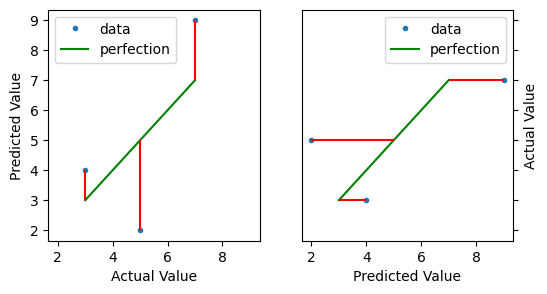

In [13]:
def regression_errors(figsize,predicted,actual,errors='all'):
    fig,axes  = plt.subplots(1,2,figsize=figsize, sharex = True, sharey = True)
    df = pd.DataFrame({'actual':actual,'predicted':predicted})
    for ax,(x,y ) in zip(axes,it.permutations(['actual','predicted'])):
        #plot the data as '.'
        ax.plot(df[x],df[y],'.',label='data')
        #plot the line as correct predictions
        ax.plot(df['actual'],df['actual'],'g-',label='perfection')
        ax.legend()

        ax.set_xlabel('{} Value'.format(x.capitalize()))
        ax.set_ylabel('{} Value'.format(y.capitalize()))
    axes[1].yaxis.tick_right()
    axes[1].yaxis.set_label_position("right")

    if errors == 'all':
        errors = range(len(df))
    if errors:
        acts = df.actual.iloc[errors]
        preds = df.predicted.iloc[errors]
        axes[0].vlines(acts,preds,acts,'r')
        axes[1].hlines(acts,preds,acts,'r')

regression_errors((6,3),ape_df.predicted,ape_df.actual)
        

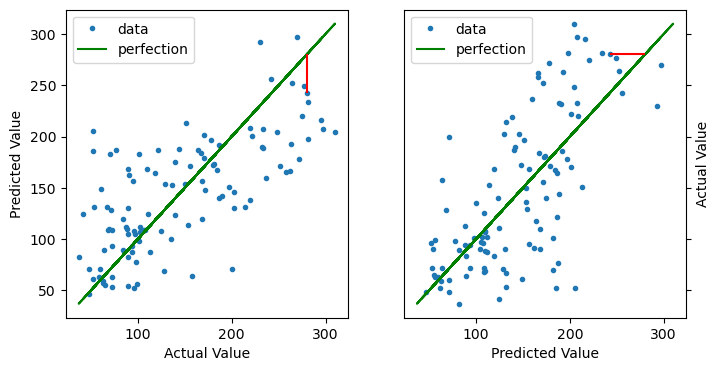

In [14]:
lr = linear_model.LinearRegression()
preds = (lr.fit(diabetes_train_ftrs,diabetes_train_tgt)).predict(diabetes_test_ftrs)
regression_errors((8,4),preds,diabetes_test_tgt,errors=[-20])

#### Residual Plots

In [15]:
ape_df = pd.DataFrame({'predicted' : [4, 2, 9],
                       'actual'    : [3, 5, 7]})

ape_df['error'] = ape_df['predicted'] - ape_df['actual']
ape_df['resid'] = ape_df['actual'] - ape_df['predicted']

ape_df.index.name = 'example'
display(ape_df)

,predicted,actual,error,resid
example,,,,
0,4,3,1,-1
1,2,5,-3,3
2,9,7,2,-2


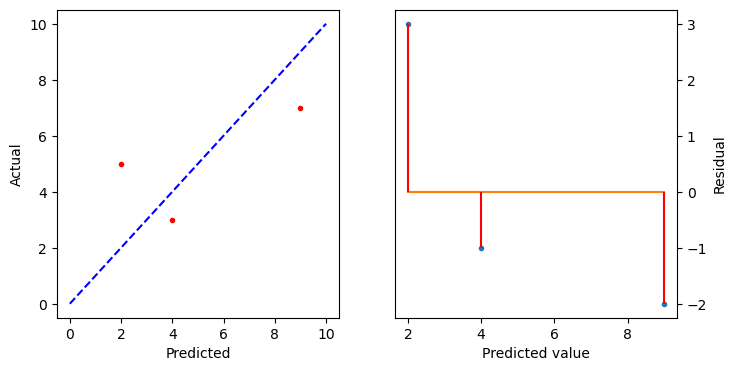

In [16]:
def regression_residuals(ax,predicted,actual,show_errors = None , right = False):
    df = pd.DataFrame({'actual':actual, 'predicted':predicted})
    df['error'] = df.actual - df.predicted
    ax.plot(df.predicted,df.error,'.')
    ax.plot(df.predicted,np.zeros_like(predicted),'-')

    if right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

        ax.set_xlabel('Predicted value')
        ax.set_ylabel('Residual')

    if show_errors =="all":
        show_errors = range(len(df))

    if show_errors:
        preds = df.predicted.iloc[show_errors]
        errors = df.error.iloc[show_errors]
        ax.vlines(preds,0,errors,'r')

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(8,4))

ax1.plot(ape_df.predicted,ape_df.actual,'r.',[0,10],[0,10],'b--')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
regression_residuals(ax2,ape_df.predicted,ape_df.actual, 'all',right = True)

Text(0.5, 1.0, 'KNN Regression Residuals')

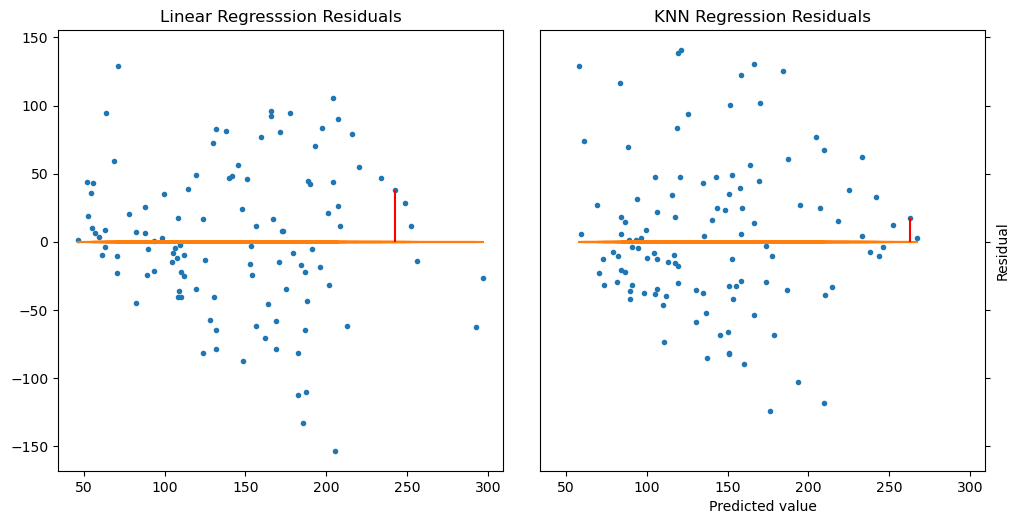

In [17]:
lr = linear_model.LinearRegression()
knn = neighbors.KNeighborsRegressor()

models = [lr,knn]

fig,axes = plt.subplots(1,2,figsize = (10,5),sharex=True, sharey=True)

fig.tight_layout()

for mod,ax, on_right in zip(models,axes,[False,True]):
    preds = (mod.fit(diabetes_train_ftrs,diabetes_train_tgt).predict(diabetes_test_ftrs))


    regression_residuals(ax,preds,diabetes_test_tgt,[-20],on_right)

axes[0].set_title("Linear Regresssion Residuals")
axes[1].set_title("KNN Regression Residuals")


In [18]:
print(diabetes_test_tgt[-20])

280.0


 #### Standardization

,x,standardized
mean,2.5000,0.0000
std,4.6706,1.0000


                      x         standardized
0               -5.0000              -1.6058
1               -4.2105              -1.4368
2               -3.4211              -1.2677
3               -2.6316              -1.0987
4               -1.8421              -0.9297
5               -1.0526              -0.7606
6               -0.2632              -0.5916
7                0.5263              -0.4226
8                1.3158              -0.2535
9                2.1053              -0.0845
10               2.8947               0.0845
11               3.6842               0.2535
12               4.4737               0.4226
13               5.2632               0.5916
14               6.0526               0.7606
15               6.8421               0.9297
16               7.6316               1.0987
17               8.4211               1.2677
18               9.2105               1.4368
19              10.0000               1.6058


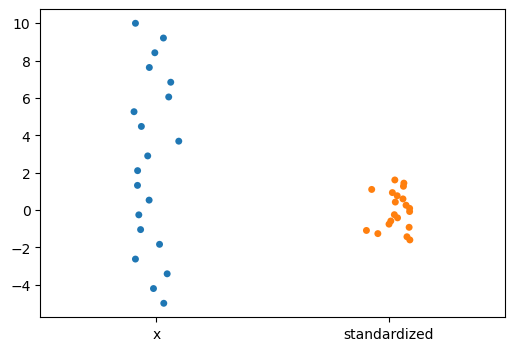

In [19]:
#1d  standardization
#first lets take evenly spaced points
xs = np.linspace(-5,10,20)
df = pd.DataFrame(xs,columns = ['x'])

#now we perfrom standization
df['standardized'] = (df.x - df.x.mean()) / df.x.std()
fig, ax = plt.subplots(1,1,figsize = (6,4))
sns.stripplot(data = df)
display(df.describe().loc[['mean','std']])
print(df)
                                

In [20]:
xs = np.linspace(-5,10,20)
ys = 3 * xs + 2 + np.random.uniform(20,40,20)

df = pd.DataFrame({"x":xs,"y":ys})
df_std_ized = (df - df.mean()) - df.std()

display(df_std_ized.describe().loc[['mean','std']])

,x,y
mean,-4.6706,-14.9532
std,4.6706,14.9532


Text(0.5, 0, 'Standardize data')

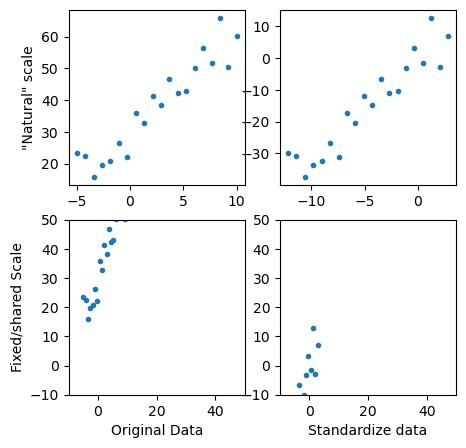

In [21]:
fig,ax = plt.subplots(2,2,figsize= (5,5))

ax[0,0].plot(df.x,df.y,'.')
ax[0,1].plot(df_std_ized.x,df_std_ized.y,'.')
ax[0,0].set_ylabel('"Natural" scale')

ax[1,0].plot(df.x,df.y,'.')
ax[1,1].plot(df_std_ized.x,df_std_ized.y,'.')

ax[1,0].axis([-10,50,-10,50])
ax[1,1].axis([-10,50,-10,50])

ax[1,0].set_ylabel('Fixed/shared Scale')
ax[1,0].set_xlabel('Original Data')
ax[1,1].set_xlabel('Standardize data')


In [22]:
train_xs, test_xs = skms.train_test_split(xs.reshape(-1,1),test_size =.5)

scaler = skpre.StandardScaler()
scaler.fit(train_xs).transform(test_xs)

array([[ 0.5726],
       [ 0.9197],
       [ 1.9608],
       [ 0.7462],
       [ 1.7873],
       [-0.295 ],
       [ 1.6138],
       [ 1.4403],
       [-0.1215],
       [ 1.0932]])

In [23]:
(train_xs,test_xs,train_ys,test_ys) = skms.train_test_split(xs.reshape(-1,1),ys.reshape(-1,1),test_size=.5)

lr = linear_model.LinearRegression()
scaler = skpre.StandardScaler()

std_lr_pipe = pipeline.make_pipeline(scaler,lr)
std_lr_pipe.fit(train_xs,train_ys).predict(test_xs)


array([[17.0989],
       [29.4954],
       [41.8919],
       [36.9333],
       [61.7263],
       [24.5368],
       [31.9747],
       [49.3298],
       [51.8091],
       [59.247 ]])

In [24]:
 ##### cross-Validated Results on Multiple metrics
student_df = pd.read_csv('data/student-math.csv',sep=';')
student_df.head()
display(student_df[['absences']].describe().T)
student_df.head()
student_df = student_df.select_dtypes(include=['number'])

student_ftrs = student_df[student_df.columns[:-1]]
print(student_ftrs)

student_tgt = student_df['G3']

,count,mean,std,min,25%,50%,75%,max
absences,395.0000,5.7089,8.0031,0.0000,0.0000,4.0000,8.0000,75.0000


     age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  \
0     18     4     4           2          2         0       4         3   
1     17     1     1           1          2         0       5         3   
2     15     1     1           1          2         3       4         3   
3     15     4     2           1          3         0       3         2   
4     16     3     3           1          2         0       4         3   
..   ...   ...   ...         ...        ...       ...     ...       ...   
390   20     2     2           1          2         2       5         5   
391   17     3     1           2          1         0       2         4   
392   21     1     1           1          1         3       5         5   
393   18     3     2           3          1         0       4         4   
394   19     1     1           1          1         0       3         2   

     goout  Dalc  Walc  health  absences  G1  G2  
0        4     1     1       3         6   5   6

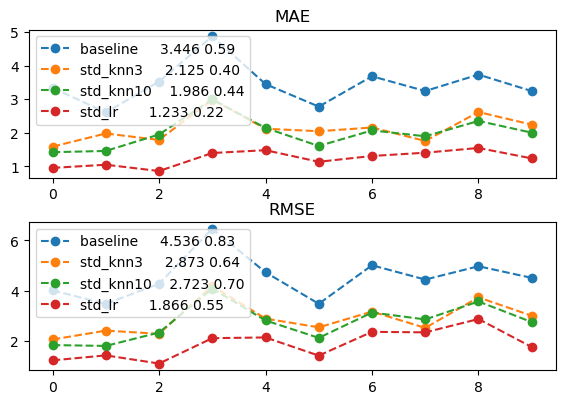

In [25]:
scaler = skpre.StandardScaler()

lr  = linear_model.LinearRegression()
knn_3 = neighbors.KNeighborsRegressor(n_neighbors=3)
knn_10 =  neighbors.KNeighborsRegressor(n_neighbors=10)

std_lr_pipe  = pipeline.make_pipeline(scaler, lr)
std_knn3_pipe  = pipeline.make_pipeline(scaler, knn_3)
std_knn10_pipe  = pipeline.make_pipeline(scaler, knn_10)

# mean with/without Standardization should give same results
regressors = {'baseline'  : dummy.DummyRegressor(strategy='mean'),
              'std_knn3'  : std_knn3_pipe,
              'std_knn10' : std_knn10_pipe,
              'std_lr'    : std_lr_pipe}

msrs = {'MAE'  : metrics.make_scorer(metrics.mean_absolute_error),
        'RMSE' : metrics.make_scorer(rms_error)}

fig, axes = plt.subplots(2, 1, figsize=(6,4))
fig.tight_layout()
for mod_name, model in regressors.items():
    cv_results = skms.cross_validate(model, 
                                     student_ftrs, student_tgt, 
                                     scoring = msrs, cv=10)

    for ax, msr in zip(axes, msrs):
        msr_results = cv_results["test_" + msr]
        my_lbl = "{:12s} {:.3f} {:.2f}".format(mod_name, 
                                               msr_results.mean(), 
                                               msr_results.std())
        ax.plot(msr_results, 'o--', label=my_lbl)
        ax.set_title(msr)
        ax.legend()

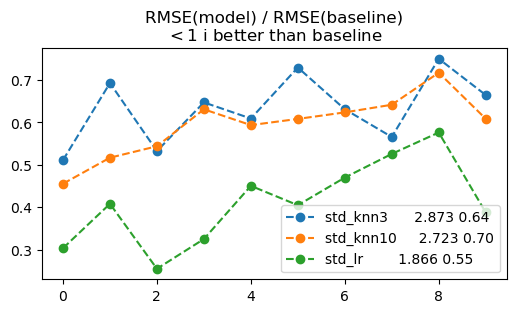

In [26]:
fig, ax = plt.subplots(1,1,figsize= (6,3))
baseline_results = skms.cross_val_score(regressors['baseline'],student_ftrs,student_tgt,scoring=msrs['RMSE'], cv=10)

for mod_name,model in regressors.items():
    if mod_name.startswith("std_"):
        cv_results = skms.cross_val_score(model,student_ftrs, student_tgt,scoring=msrs['RMSE'], cv = 10)

        my_lbl = "{:12s}  {:.3f} {:.2f}".format(mod_name, cv_results.mean(), cv_results.std())

        ax.plot(cv_results / baseline_results, 'o--', label = my_lbl)

ax.set_title("RMSE(model) / RMSE(baseline)\n$<1$ i better than baseline")
ax.legend()

Text(0.5, 1.0, '$R^2$')

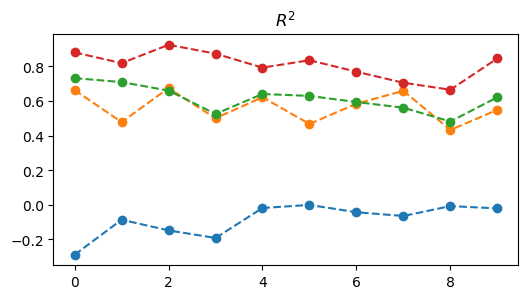

In [27]:
fig, ax = plt.subplots(1,1,figsize = (6,3))
for mod_name, model in regressors.items():
    cv_score = skms.cross_val_score(model, student_ftrs, student_tgt, cv = 10)
    my_lbl = "{:12s}  {:.3f} {:.2f}".format(mod_name, cv_results.mean(), cv_results.std())
    ax.plot(cv_score,'o--',label = my_lbl)

ax.set_title("$R^2$")


#### Summarizing Cross-validated Results

In [48]:
msrs = {
    'MAD':metrics.mean_absolute_error,
    'RMSE':rms_error
}

results = {}
for mod_name, model in regressors.items():
    cv_preds = skms.cross_val_predict(model,student_ftrs,student_tgt,cv=10)

    for ax,msr in zip(axes,msrs):
        msr_results = msrs[msr](student_tgt,cv_preds)
        results.setdefault(msr,[]).append(msr_results)

df = pd.DataFrame(results,index= regressors.keys())
df    

,MAD,RMSE
baseline,3.4470,4.6116
std_knn3,2.1241,2.9422
std_knn10,1.9863,2.8113
std_lr,1.2324,1.9425


,G3
count,395.0000
mean,10.4152
std,4.5814
min,0.0000
25%,8.0000
50%,11.0000
75%,14.0000
max,20.0000


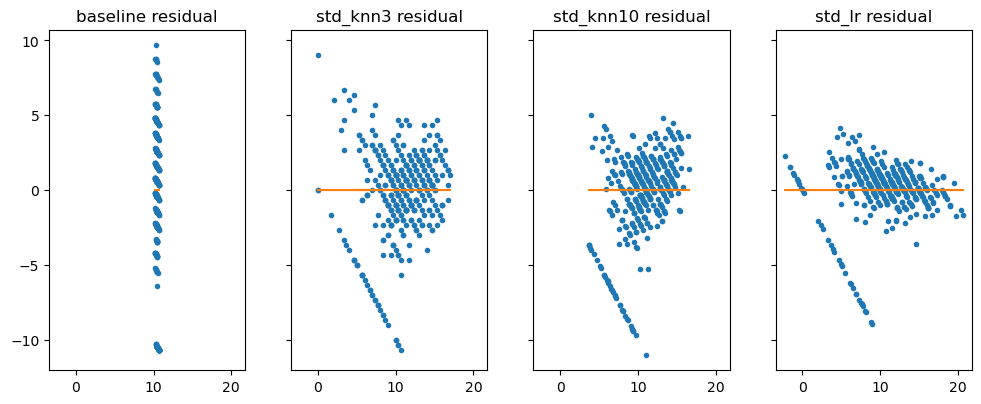

In [53]:
fig , axes = plt.subplots(1,4,figsize=(10,4),sharex = True, sharey = True)
fig.tight_layout()

for model_name, ax in zip(regressors,axes):
    model = regressors[model_name]
    cv_preds = skms.cross_val_predict(model, student_ftrs, student_tgt, cv = 10)
    regression_residuals(ax,cv_preds,student_tgt)
    ax.set_title(model_name +" residual")

pd.DataFrame(student_tgt.describe().T)